In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Jupyter + venv working")


Jupyter + venv working


In [2]:
path = r"C:\Users\rohit\OneDrive\Desktop\Presto_Portfolio_Sample_Table.xlsx"

df = pd.read_excel(path, sheet_name='Fare_Data')

In [3]:
df.head()

,Date,Year,Month,Weekday,Time,Hour,Transaction_Type,Amount,Location,Commute_Tag
0,2025-11-17,2025,November,Monday,18:15,18,Fare Payment,4.12,VALLEYMEDE DR / HWY 7,Leisure
1,2025-12-23,2025,December,Tuesday,15:10,15,Fare Payment,4.12,LESLIE ST / HIGHWAY 7,Work Commute
2,2025-12-01,2025,December,Monday,07:15,7,Fare Payment,4.12,HIGH TECH RD / RED MAPLE RD,Errand
3,2025-12-06,2025,December,Saturday,06:15,6,Free Transfer,0.00,YONGE ST / 16TH AVE,Work Commute
4,2025-10-16,2025,October,Thursday,07:30,7,Fare Payment,4.12,RICHMOND HILL CENTRE,Errand


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              220 non-null    datetime64[ns]
 1   Year              220 non-null    int64         
 2   Month             220 non-null    object        
 3   Weekday           220 non-null    object        
 4   Time              220 non-null    object        
 5   Hour              220 non-null    int64         
 6   Transaction_Type  220 non-null    object        
 7   Amount            220 non-null    float64       
 8   Location          220 non-null    object        
 9   Commute_Tag       220 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 17.3+ KB


In [6]:
df.describe(include="all")

,Date,Year,Month,Weekday,Time,Hour,Transaction_Type,Amount,Location,Commute_Tag
count,220,220.0,220,220,220,220.000000,220,220.000000,220,220
unique,NaN,NaN,3,7,79,NaN,2,NaN,8,3
top,NaN,NaN,October,Sunday,08:45,NaN,Fare Payment,NaN,DON MILLS STATION,Work Commute
freq,NaN,NaN,80,46,7,NaN,150,NaN,35,82
mean,2025-11-14 08:50:10.909090816,2025.0,NaN,NaN,NaN,12.159091,NaN,2.809091,NaN,NaN
min,2025-10-02 00:00:00,2025.0,NaN,NaN,NaN,6.000000,NaN,0.000000,NaN,NaN
25%,2025-10-19 00:00:00,2025.0,NaN,NaN,NaN,7.000000,NaN,0.000000,NaN,NaN
50%,2025-11-16 12:00:00,2025.0,NaN,NaN,NaN,15.000000,NaN,4.120000,NaN,NaN
75%,2025-12-07 00:00:00,2025.0,NaN,NaN,NaN,16.250000,NaN,4.120000,NaN,NaN
max,2025-12-30 00:00:00,2025.0,NaN,NaN,NaN,18.000000,NaN,4.120000,NaN,NaN


In [7]:
paid = df[df["Transaction_Type"] == "Fare Payment"].copy()

monthly = (paid
           .groupby(pd.Grouper(key="Date", freq="MS"))["Amount"]
           .sum()
           .reset_index()
           .rename(columns={"Amount":"MonthlySpend"}))

monthly


,Date,MonthlySpend
0,2025-10-01,206.00
1,2025-11-01,201.88
2,2025-12-01,210.12


In [8]:
peak_hour = (paid.groupby("Hour")
             .size()
             .sort_values(ascending=False)
             .head(10))

peak_hour


Hour
8     23
16    23
7     22
17    22
15    21
6     20
18    19
dtype: int64

In [9]:
top_locations = (paid["Location"]
                 .value_counts()
                 .head(10))

top_locations


Location
DON MILLS STATION               25
LESLIE ST / HIGHWAY 7           23
YONGE ST / 16TH AVE             22
BAYVIEW AV / MAJOR MACKENZIE    21
RICHMOND HILL CENTRE            18
VALLEYMEDE DR / HWY 7           15
HIGH TECH RD / RED MAPLE RD     14
FINCH STATION                   12
Name: count, dtype: int64

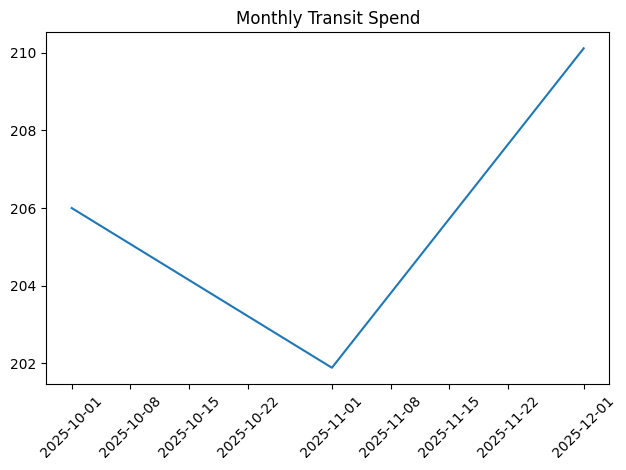

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly["Date"], monthly["MonthlySpend"])
plt.xticks(rotation=45)
plt.title("Monthly Transit Spend")
plt.tight_layout()
plt.show()
